# AptiForge - Model Evaluation

## Objective

The objective of this notebook is to evaluate the performance of the trained Random Forest Classifier using various classification metrics. These evaluation metrics help determine how accurately the model predicts the student's aptitude skill level.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load Dataset

In [2]:
students = pd.read_csv("../datasets/student_performance.csv")

students.head()

,StudentID,QuestionsAttempted,CorrectAnswers,WrongAnswers,Accuracy,AverageResponseTime,EasyCorrect,MediumCorrect,HardCorrect,EasyWrong,MediumWrong,HardWrong,CurrentDifficulty,LongestCorrectStreak,ConfidenceScore,FinalScore,SkillLevel
0,1,30,23,7,76.67,39,10,8,5,0,2,5,Hard,10,57,41,Intermediate
1,2,30,26,4,86.67,36,8,7,11,2,3,0,Medium,5,82,55,Intermediate
2,3,30,26,4,86.67,21,10,10,6,0,0,4,Hard,8,100,48,Advanced
3,4,30,25,5,83.33,33,8,7,10,2,3,0,Hard,10,54,52,Intermediate
4,5,30,23,7,76.67,19,10,8,5,0,2,5,Hard,15,75,41,Advanced


## Step 3: Select Features and Target Variable

In [3]:
features = [
    "QuestionsAttempted",
    "CorrectAnswers",
    "WrongAnswers",
    "Accuracy",
    "AverageResponseTime",
    "EasyCorrect",
    "MediumCorrect",
    "HardCorrect",
    "LongestCorrectStreak",
    "ConfidenceScore",
    "FinalScore"
]

X = students[features]

y = students["SkillLevel"]

## Step 4: Encode Target Variable

In [4]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

## Step 5: Split Dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Step 6: Train the Random Forest Classifier

In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Step 7: Calculate Accuracy

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.995


## Step 8: Calculate Precision

In [8]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 0.9950333350297725


## Step 9: Calculate Recall

In [9]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall:", recall)

Recall: 0.995


## Step 10: Calculate F1-Score

In [10]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1 Score:", f1)

F1 Score: 0.9950035037426341


## Step 11: Generate Classification Report

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       291
           1       1.00      1.00      1.00       305
           2       1.00      0.99      0.99       404

    accuracy                           0.99      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      0.99      1.00      1000



## Step 12: Generate Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[290   0   1]
 [  0 305   0]
 [  4   0 400]]


## Step 13: Visualize Confusion Matrix

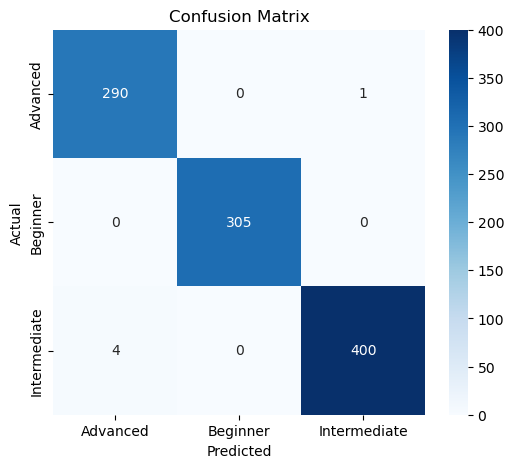

In [13]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Step 14: Display Feature Importance

Feature importance indicates how much each feature contributes to the prediction made by the Random Forest model.

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,MediumCorrect,0.260701
4,AverageResponseTime,0.141916
9,ConfidenceScore,0.121910
8,LongestCorrectStreak,0.112904
5,EasyCorrect,0.098588
3,Accuracy,0.090119
2,WrongAnswers,0.080745
1,CorrectAnswers,0.069177
7,HardCorrect,0.016153
10,FinalScore,0.007787


## Step 15: Visualize Feature Importance

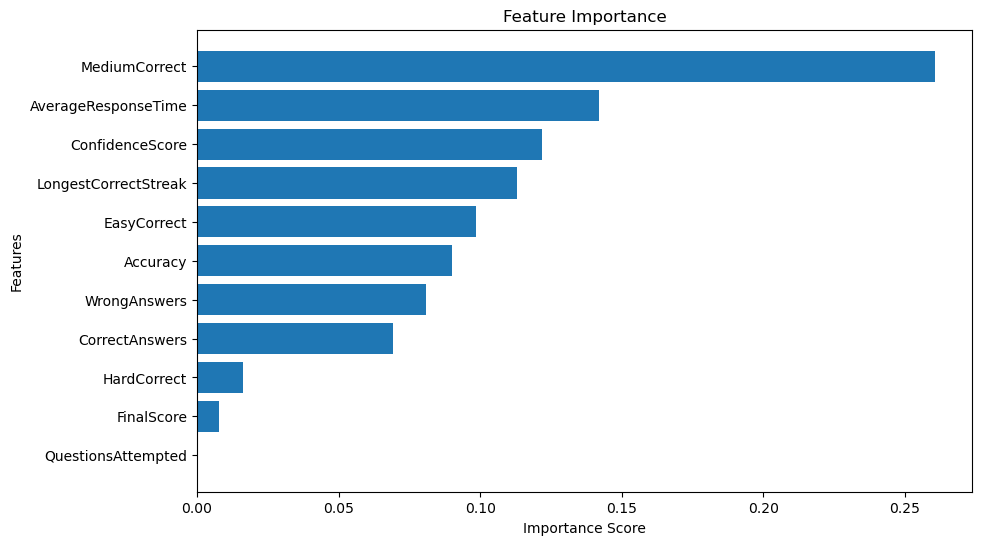

In [15]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## Conclusion

The Random Forest Classifier was successfully evaluated using multiple classification metrics.

The model achieved high prediction performance based on Accuracy, Precision, Recall, and F1-Score. The Confusion Matrix and Feature Importance analysis provide additional insights into the model's prediction capability.

The trained model is now ready to be saved and integrated into the AptiForge web application.